In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

# Set the directory where `.dat` files are stored
data_folder = "./"  # Change this to your folder path

# Get all `.dat` files in the directory
file_list = [os.path.join(data_folder, f) for f in os.listdir(data_folder) if f.endswith('.dat')]

# Function to read and clean a single `.dat` file
def load_and_clean_data(file_path):
    with open(file_path, 'r', encoding='utf-8') as file:
        lines = file.readlines()

    # Find where the actual data starts
    data_start = next(i for i, line in enumerate(lines) if "HeaderEnd" in line) + 1

    # Read the data part (after "HeaderEnd")
    data_lines = lines[data_start:]

    # Convert to dataframe using semicolon (;) as a separator
    df = pd.DataFrame([line.strip().split(';') for line in data_lines])

    # Drop empty columns
    df.dropna(axis=1, how='all', inplace=True)

    # Assign proper column names manually
    df.columns = [
        "Session Time", "Volume (liters)", "Balloon Valve Status",
        "Patient Switch", "Gating Mode", "Gating Status", "Relay State"
    ]

    # Convert necessary columns to numeric values (handling missing values)
    df["Session Time"] = pd.to_numeric(df["Session Time"], errors="coerce")
    df["Volume (liters)"] = pd.to_numeric(df["Volume (liters)"], errors="coerce")
    
    # Replace missing `-` with NaN
    df.replace('-', np.nan, inplace=True)

    return df

# Load all files and combine them
all_data = pd.concat([load_and_clean_data(file) for file in file_list], ignore_index=True)

# Print shape and sample of the cleaned dataset
print("Loaded data shape:", all_data.shape)
print(all_data.head())



Loaded data shape: (1426955, 7)
   Session Time  Volume (liters) Balloon Valve Status Patient Switch  \
0          4.88            0.312                    1              0   
1          4.90            0.320                    1              0   
2          4.92            0.328                    1              0   
3          4.94            0.336                    1              0   
4          4.96            0.344                    1              0   

      Gating Mode Gating Status Relay State  
0  Manual Overide                            
1              -             -            -  
2              -             -            -  
3              -             -            -  
4              -             -            -  


In [2]:
# Load all files and combine them
all_data = pd.concat([load_and_clean_data(file) for file in file_list], ignore_index=True)


In [3]:
# Fill missing values
all_data.fillna(method='ffill', inplace=True)  # Forward fill missing values

# Convert categorical columns using Label Encoding
categorical_cols = ['Gating Mode', 'Gating Status', 'Relay State']
encoder = LabelEncoder()
for col in categorical_cols:
    all_data[col] = encoder.fit_transform(all_data[col].astype(str))  # Convert NaNs to "unknown"

# Feature Engineering: Calculate Rate of Change of Volume
all_data['Volume Change'] = all_data['Volume (liters)'].diff().fillna(0)

# Moving Average of Volume (to smooth breathing pattern)
all_data['Volume MA'] = all_data['Volume (liters)'].rolling(window=5).mean().fillna(all_data['Volume (liters)'])


C:\Users\Administrator\AppData\Local\Temp\ipykernel_10564\853219119.py:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  all_data.fillna(method='ffill', inplace=True)  # Forward fill missing values


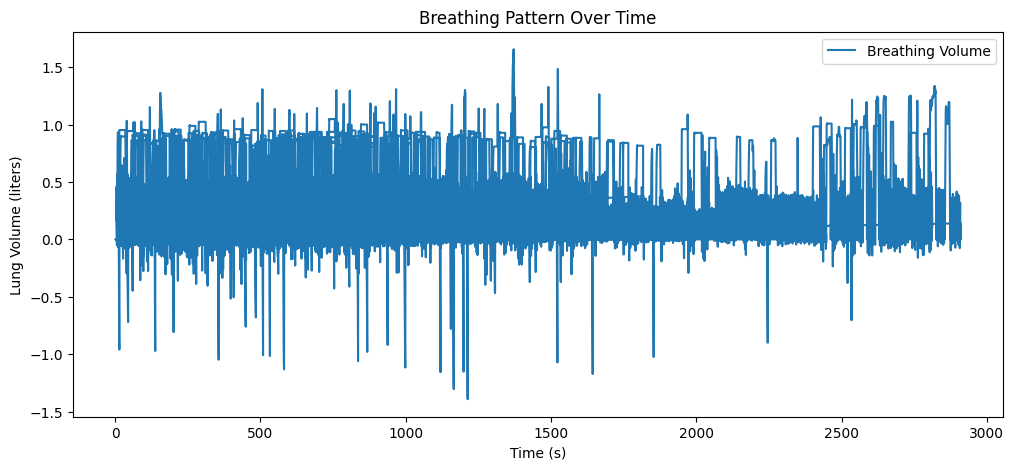

In [4]:
plt.figure(figsize=(12,5))
plt.plot(all_data['Session Time'], all_data['Volume (liters)'], label="Breathing Volume")
plt.xlabel('Time (s)')
plt.ylabel('Lung Volume (liters)')
plt.title('Breathing Pattern Over Time')
plt.legend()
plt.show()


In [5]:
# Define features and target variable
X = all_data[['Session Time', 'Volume (liters)', 'Volume Change', 'Volume MA', 'Gating Mode', 'Gating Status']]
y = all_data['Volume (liters)'].shift(-1).fillna(all_data['Volume (liters)'])  # Predict next volume step

# Split into training and testing data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Normalize the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [6]:
# Train a Random Forest Regressor
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train_scaled, y_train)

# Make predictions
y_pred = model.predict(X_test_scaled)

# Evaluate model
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("Model RMSE:", rmse)


Model RMSE: 0.012673601219707889


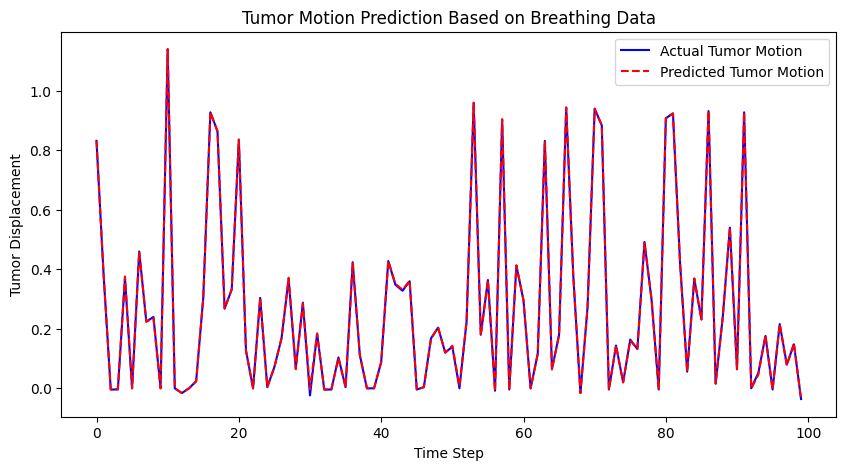

In [7]:
plt.figure(figsize=(10,5))
plt.plot(y_test.values[:100], label="Actual Tumor Motion", color='blue')
plt.plot(y_pred[:100], label="Predicted Tumor Motion", linestyle="dashed", color='red')
plt.xlabel("Time Step")
plt.ylabel("Tumor Displacement")
plt.legend()
plt.title("Tumor Motion Prediction Based on Breathing Data")
plt.show()


In [ ]:
#Deploy Advanced LSTM Model for Better Predictions

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# Reshape data for LSTM (samples, time steps, features)
X_train_lstm = X_train_scaled.reshape(X_train_scaled.shape[0], 1, X_train_scaled.shape[1])
X_test_lstm = X_test_scaled.reshape(X_test_scaled.shape[0], 1, X_test_scaled.shape[1])

# Build LSTM model
lstm_model = Sequential([
    LSTM(50, return_sequences=True, input_shape=(1, X_train_scaled.shape[1])),
    LSTM(50, return_sequences=False),
    Dense(25, activation="relu"),
    Dense(1)
])

# Compile model
lstm_model.compile(optimizer="adam", loss="mean_squared_error")

# Train LSTM
lstm_model.fit(X_train_lstm, y_train, epochs=20, batch_size=32, validation_data=(X_test_lstm, y_test))



In [ ]:
# Predict with LSTM
y_pred_lstm = lstm_model.predict(X_test_lstm)

# Plot results
plt.figure(figsize=(10,5))
plt.plot(y_test.values[:100], label="Actual Tumor Motion", color='blue')
plt.plot(y_pred_lstm[:100], label="LSTM Predicted Motion", linestyle="dashed", color='green')
plt.xlabel("Time Step")
plt.ylabel("Tumor Displacement")
plt.legend()
plt.title("Tumor Motion Prediction Using LSTM")
plt.show()
